In [1]:
import keras
from keras import layers, Sequential
import keras_hub

2026-06-16 13:54:21.897594: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781618062.086727      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781618062.140931      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781618062.594087      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781618062.594123      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781618062.594129      58 computation_placer.cc:177] computation placer alr

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar100.load_data()

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
print(f"SIZE OF THE TRAINING DATA : {len(x_train)}")
print(f"SIZE OF THE TEST DATA : {len(x_test)}")

SIZE OF THE TRAINING DATA : 50000
SIZE OF THE TEST DATA : 10000


### Since keras doesn't store the label names, Hence these below are the label names for all the CIFAR100 classes


"apple", "aquarium_fish", "baby", "bear", "beaver", "bed", "bee", "beetle",<br>
"bicycle", "bottle", "bowl", "boy", "bridge", "bus", "butterfly", "camel", <br>
"can", "castle", "caterpillar", "cattle", "chair", "chimpanzee", "clock", <br>
"cloud", "cockroach", "couch", "crab", "crocodile", "cup", "dinosaur", <br>
"dolphin", "elephant", "flatfish", "forest", "fox", "girl", "hamster", <br>
"house", "kangaroo", "keyboard", "lamp", "lawn_mower", "leopard", "lion", <br>
"lizard", "lobster", "man", "maple_tree", "motorcycle", "mountain", "mouse", <br>
"mushroom", "oak_tree", "orange", "orchid", "otter", "palm_tree", "pear", <br>
"pickup_truck", "pine_tree", "plain", "plate", "poppy", "porcupine", <br>
"possum", "rabbit", "raccoon", "ray", "road", "rocket", "rose", "sea", <br>
"seal", "shark", "shrew", "skunk", "skyscraper", "snail", "snake", "spider", <br>
"squirrel", "streetcar", "sunflower", "sweet_pepper", "table", "tank", <br>
"telephone", "television", "tiger", "tractor", "train", "trout", "tulip", <br>
"turtle", "wardrobe", "whale", "willow_tree", "wolf", "woman", "worm"



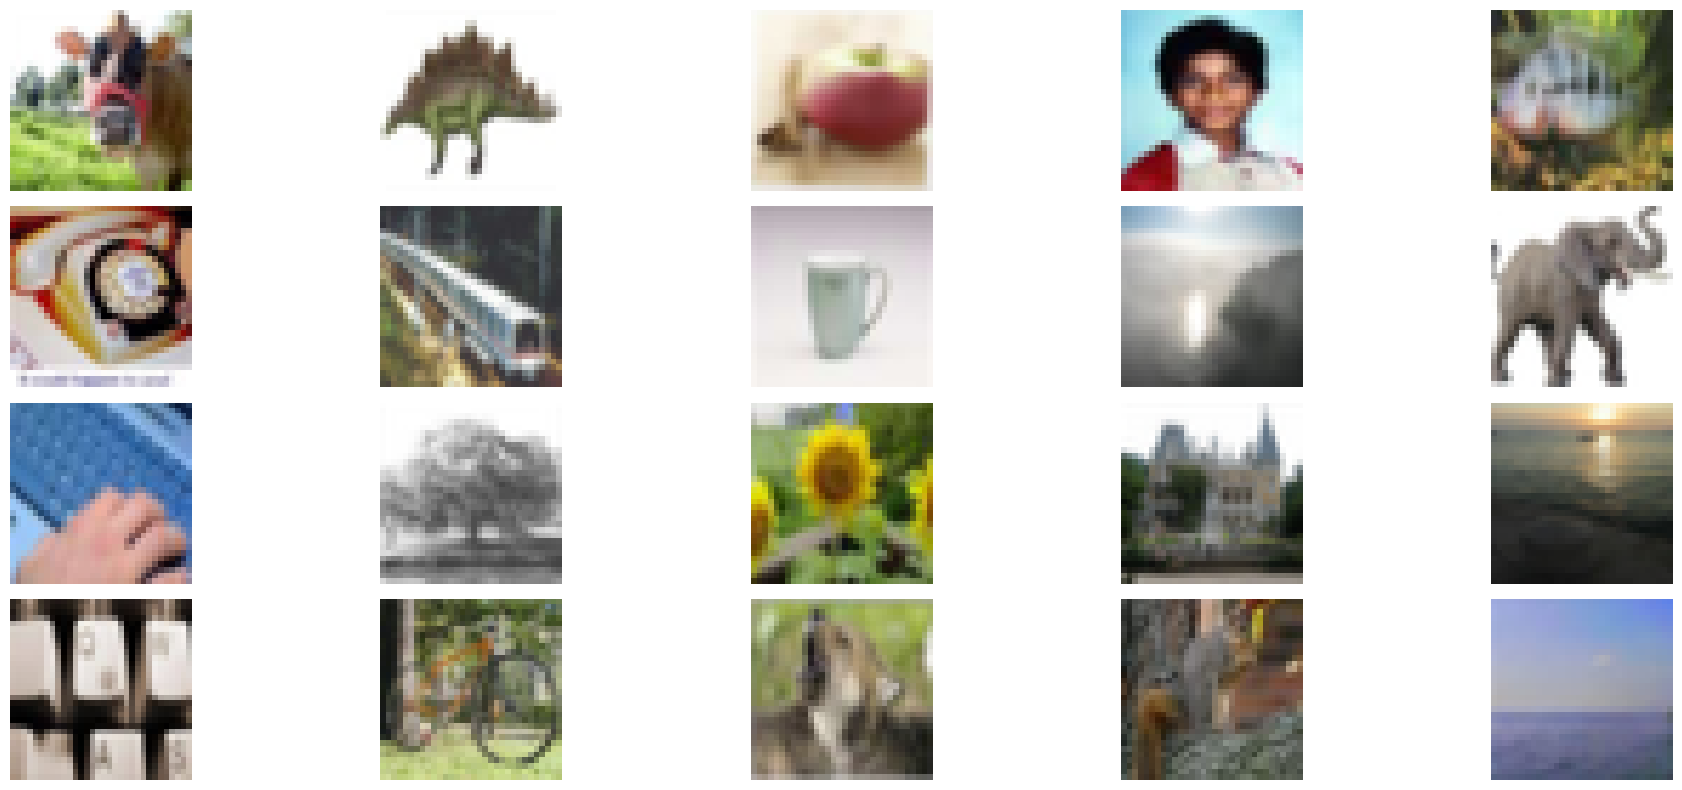

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))
for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(x_train[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
import numpy as np

In [13]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

mean = np.array([0.485, 0.456, 0.406], dtype="float32")
std = np.array([0.229, 0.224, 0.225], dtype="float32")

x_train = (x_train - mean) / std
x_test = (x_test - mean) / std



base_model = keras_hub.models.Backbone.from_preset("densenet_201_imagenet")

base_model.trainable=False

In [17]:
model = Sequential([
    layers.Resizing(128, 128),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(100, activation="softmax")
])


In [18]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=5,
    batch_size=64
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 158s 158ms/step - accuracy: 0.0105 - loss: 4.6756 - val_accuracy: 0.0100 - val_loss: 4.6400
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.0101 - loss: 4.6556 - val_accuracy: 0.0100 - val_loss: 4.6331
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 90ms/step - accuracy: 0.0090 - loss: 4.6538 - val_accuracy: 0.0100 - val_loss: 4.6397
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 90ms/step - accuracy: 0.0094 - loss: 4.6527 - val_accuracy: 0.0100 - val_loss: 4.6339
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 90ms/step - accuracy: 0.0095 - loss: 4.6545 - val_accuracy: 0.0100 - val_loss: 4.6356


### saving the model

In [19]:
model.save('cifar100_model.keras')